In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# set random seed for reproducibility
np.random.seed(42)

# QUESTION 10

In [42]:
# given price array: 2 stocks x 12 months
prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]   # Stock B
])

In [ ]:
# Q10 (a)

# compute monthly simple returns: R_t = (P_t - P_{t-1}) / P_{t-1}
# using slicing: numerator is prices from col 1 onwards minus prices up to col 11
# denominator is prices up to col 11
# result shape: (2, 11)

simple_returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]

print("Q10 (a) - Monthly Simple Returns (shape:", simple_returns.shape, ")")
print("Stock A returns:", np.round(simple_returns[0], 4))
print("Stock B returns:", np.round(simple_returns[1], 4))


Q10 (a) - Monthly Simple Returns (shape: (2, 11) )
Stock A returns: [ 0.08   -0.0463  0.1165 -0.0435  0.0818  0.0504 -0.032   0.0744 -0.0231
  0.063   0.037 ]
Stock B returns: [-0.025   0.0769 -0.0238  0.0732 -0.0227  0.0465  0.0222 -0.0348  0.0586
  0.0213 -0.0083]


In [44]:
# Q10 (b)

# annualised mean return = monthly mean * 12
# annualised std dev = monthly std * sqrt(12)
# axis=1 means we compute across the 11 months for each stock

monthly_mean = simple_returns.mean(axis=1)      # shape (2,)
monthly_std  = simple_returns.std(axis=1, ddof=1)  # sample std, shape (2,)

annualised_mean = monthly_mean * 12
annualised_std  = monthly_std * np.sqrt(12)

print("\nQ10 (b) - Annualised Statistics")
print("Stock A - Ann. Mean Return: {:.4f}, Ann. Std Dev: {:.4f}".format(
    annualised_mean[0], annualised_std[0]))
print("Stock B - Ann. Mean Return: {:.4f}, Ann. Std Dev: {:.4f}".format(
    annualised_mean[1], annualised_std[1]))



Q10 (b) - Annualised Statistics
Stock A - Ann. Mean Return: 0.3909, Ann. Std Dev: 0.2020
Stock B - Ann. Mean Return: 0.2007, Ann. Std Dev: 0.1458


In [45]:
# Q10 (c)

# np.cov computes the 2x2 sample covariance matrix from the return rows
# rowvar=True means each row is a variable (each stock is a row)
cov_matrix = np.cov(simple_returns)   # shape (2, 2)

# extract individual standard deviations from cov matrix diagonal
sigma_A = np.sqrt(cov_matrix[0, 0])
sigma_B = np.sqrt(cov_matrix[1, 1])

# correlation between A and B from covariance
rho_AB = cov_matrix[0, 1] / (sigma_A * sigma_B)

# verify: off-diagonal of cov should equal rho * sigma_A * sigma_B
off_diagonal_from_cov    = cov_matrix[0, 1]
off_diagonal_recomputed  = rho_AB * sigma_A * sigma_B

print("\nQ10 (c) - 2x2 Sample Covariance Matrix:")
print(cov_matrix)
print("Off-diagonal from np.cov:      {:.8f}".format(off_diagonal_from_cov))
print("rho * sigma_A * sigma_B:       {:.8f}".format(off_diagonal_recomputed))
print("Match:", np.isclose(off_diagonal_from_cov, off_diagonal_recomputed))




Q10 (c) - 2x2 Sample Covariance Matrix:
[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]
Off-diagonal from np.cov:      -0.00206426
rho * sigma_A * sigma_B:       -0.00206426
Match: True




# QUESTION 11



In [46]:


# mu vector (expected returns)
mu_3 = np.array([0.15, 0.08, 0.05])

# individual standard deviations
sigma_3 = np.array([0.25, 0.12, 0.04])

# correlation matrix
rho_matrix = np.array([
    [1.0, 0.4, 0.1],
    [0.4, 1.0, 0.2],
    [0.1, 0.2, 1.0]
])

# covariance matrix: Sigma_ij = rho_ij * sigma_i * sigma_j
# outer product of sigma with itself gives sigma_i * sigma_j for all i,j
Sigma_3 = rho_matrix * np.outer(sigma_3, sigma_3)

print("\nQ11 - 3-Asset Covariance Matrix:")
print(Sigma_3)



Q11 - 3-Asset Covariance Matrix:
[[0.0625  0.012   0.001  ]
 [0.012   0.0144  0.00096]
 [0.001   0.00096 0.0016 ]]


In [47]:


# Q11 (a)

# equal weight portfolio
w_eq = np.array([1/3, 1/3, 1/3])

# portfolio expected return: w^T * mu
E_Rp_eq = w_eq @ mu_3

# portfolio variance: w^T * Sigma * w
var_p_eq = w_eq @ Sigma_3 @ w_eq

# portfolio std dev
sigma_p_eq = np.sqrt(var_p_eq)

print("\nQ11 (a) - Equal-Weight Portfolio")
print("E[Rp] = {:.4f}".format(E_Rp_eq))
print("sigma_p^2 = {:.6f}".format(var_p_eq))
print("sigma_p = {:.4f}".format(sigma_p_eq))



Q11 (a) - Equal-Weight Portfolio
E[Rp] = 0.0933
sigma_p^2 = 0.011824
sigma_p = 0.1087


In [48]:

# Q11 (b)

# generate 10000 random weight vectors using Dirichlet distribution
# alpha=[1,1,1] gives uniform distribution over the simplex
np.random.seed(42)
N_sim = 10000
weights_sim = np.random.dirichlet(alpha=[1, 1, 1], size=N_sim)  # shape (10000, 3)

# expected returns for all portfolios: matrix multiply weights by mu
# weights_sim @ mu_3 -> shape (10000,)
E_Rp_all = weights_sim @ mu_3

# portfolio variance for all portfolios: w^T Sigma w for each row
# (weights_sim @ Sigma_3) gives shape (10000, 3)
# then elementwise multiply by weights_sim and sum across assets
var_p_all = np.sum((weights_sim @ Sigma_3) * weights_sim, axis=1)  # shape (10000,)

# portfolio std dev for all portfolios
sigma_p_all = np.sqrt(var_p_all)

print("\nQ11 (b) - Random Portfolio Simulation")
print("Shape of E_Rp_all:", E_Rp_all.shape)
print("Shape of sigma_p_all:", sigma_p_all.shape)



Q11 (b) - Random Portfolio Simulation
Shape of E_Rp_all: (10000,)
Shape of sigma_p_all: (10000,)


In [49]:

# Q11 (c)

# risk-free rate for Sharpe computation
Rf_q11 = 0.04  # 4% as mentioned in Q7

# Sharpe ratio for all 10000 portfolios (vectorised, no loop)
sharpe_all = (E_Rp_all - Rf_q11) / sigma_p_all  # shape (10000,)

# find index of maximum Sharpe ratio
idx_max_sharpe = np.argmax(sharpe_all)

max_sharpe        = sharpe_all[idx_max_sharpe]
max_sharpe_weights = weights_sim[idx_max_sharpe]
max_sharpe_ret    = E_Rp_all[idx_max_sharpe]
max_sharpe_sigma  = sigma_p_all[idx_max_sharpe]

print("\nQ11 (c) - Maximum Sharpe Ratio Portfolio")
print("Max Sharpe Ratio: {:.4f}".format(max_sharpe))
print("Weights: Asset1={:.4f}, Asset2={:.4f}, Asset3={:.4f}".format(
    *max_sharpe_weights))
print("E[Rp]: {:.4f}, sigma_p: {:.4f}".format(max_sharpe_ret, max_sharpe_sigma))



Q11 (c) - Maximum Sharpe Ratio Portfolio
Max Sharpe Ratio: 0.5053
Weights: Asset1=0.2034, Asset2=0.1715, Asset3=0.6251
E[Rp]: 0.0755, sigma_p: 0.0702



# QUESTION 12



In [50]:

# two-asset parameters
mu1_q12  = 0.12   # 12%
sigma1_q12 = 0.20  # 20%
mu2_q12  = 0.06   # 6%
sigma2_q12 = 0.10  # 10%
w1_q12   = 0.6
w2_q12   = 1 - w1_q12  # 0.4


In [51]:


# Q12 (a)

# create 200 equally-spaced correlation values in [-1, +1]
rho_array = np.linspace(-1, 1, 200)  # shape (200,)

# portfolio variance formula (vectorised, no loop):
# sigma_p^2 = w1^2*s1^2 + w2^2*s2^2 + 2*w1*w2*rho*s1*s2
var_p_q12 = (w1_q12**2 * sigma1_q12**2
             + w2_q12**2 * sigma2_q12**2
             + 2 * w1_q12 * w2_q12 * rho_array * sigma1_q12 * sigma2_q12)

sigma_p_q12 = np.sqrt(var_p_q12)  # shape (200,)

print("\nQ12 (a) - Portfolio Std Dev array shape:", sigma_p_q12.shape)
print("Sample values (first 3):", sigma_p_q12[:3])



Q12 (a) - Portfolio Std Dev array shape: (200,)
Sample values (first 3): [0.08       0.08060076 0.08119707]


In [52]:


# Q12 (b)

# find rho that minimises sigma_p
idx_min = np.argmin(sigma_p_q12)
rho_min = rho_array[idx_min]
sigma_p_min = sigma_p_q12[idx_min]

print("\nQ12 (b) - Minimum Portfolio Risk")
print("rho at minimum sigma_p: {:.4f}".format(rho_min))
print("Minimum sigma_p: {:.4f}".format(sigma_p_min))



Q12 (b) - Minimum Portfolio Risk
rho at minimum sigma_p: -1.0000
Minimum sigma_p: 0.0800


In [53]:


# Q12 (c)

# analytical verification: differentiate variance w.r.t. rho
# d(sigma_p^2)/d(rho) = 2 * w1 * w2 * sigma1 * sigma2
# this derivative is always positive (all terms > 0 for w1,w2,s1,s2 > 0)
# so variance is monotonically increasing in rho
# meaning minimum variance always occurs at rho = -1 (boundary)

d_var_d_rho = 2 * w1_q12 * w2_q12 * sigma1_q12 * sigma2_q12
print("\nQ12 (c) - Analytical Verification")
print("d(sigma_p^2)/d(rho) = {:.6f} > 0 always".format(d_var_d_rho))
print("Variance is strictly increasing in rho.")
print("Therefore minimum sigma_p always at rho = -1 (left boundary).")
print("sigma_p at rho=-1: {:.4f}".format(sigma_p_q12[0]))




Q12 (c) - Analytical Verification
d(sigma_p^2)/d(rho) = 0.009600 > 0 always
Variance is strictly increasing in rho.
Therefore minimum sigma_p always at rho = -1 (left boundary).
sigma_p at rho=-1: 0.0800




# QUESTION 13



In [ ]:

np.random.seed(0)   # same seed as in question
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly  = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04,  0.03,  0.02,  0.025])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim  = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates,
                  columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])


In [55]:


# Q13 (a)

# compute weekly simple returns using pct_change
# pct_change() computes (current - previous) / previous
# dropna() removes the first NaN row (no previous price for first row)
df_returns = df.pct_change().dropna()

print("\nQ13 (a) - Weekly Simple Returns")
print("First 3 rows:")
print(df_returns.head(3))
print("Shape of returns DataFrame:", df_returns.shape)



Q13 (a) - Weekly Simple Returns
First 3 rows:
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842
Shape of returns DataFrame: (51, 4)


In [ ]:

# Q13 (b)

# describe() gives count, mean, std, min, max, quartiles
desc = df_returns.describe()
print("\nQ13 (b) - Descriptive Statistics:")
print(desc)

# identify highest mean return and highest std dev
highest_mean_asset = desc.loc['mean'].idxmax()
highest_std_asset  = desc.loc['std'].idxmax()

print("Asset with highest mean return:", highest_mean_asset)
print("Asset with highest std deviation:", highest_std_asset)



Q13 (b) - Descriptive Statistics:
            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -0.000365   0.009468
75%     0.039082   0.028178   0.009462   0.020051
max     0.098326   0.060309   0.044265   0.050269
Asset with highest mean return: AMZN
Asset with highest std deviation: AAPL


In [57]:


# Q13 (c)

# annualised Sharpe Ratio for each asset
# Rf = 2% annualised = 2%/52 per week
Rf_annual  = 0.02
Rf_weekly  = Rf_annual / 52   # convert to weekly risk-free rate

# annualised mean = weekly mean * 52
# annualised std  = weekly std * sqrt(52)
ann_mean_ret = df_returns.mean() * 52
ann_std_ret  = df_returns.std()  * np.sqrt(52)

# Sharpe Ratio (annualised)
sharpe_assets = (ann_mean_ret - Rf_annual) / ann_std_ret

print("\nQ13 (c) - Annualised Sharpe Ratios:")
print(sharpe_assets)



Q13 (c) - Annualised Sharpe Ratios:
AAPL     0.824485
MSFT     0.397113
GOOGL   -0.537553
AMZN     1.794045
dtype: float64





# QUESTION 14




In [58]:

# Q14 (a)

# compute 4x4 correlation matrix
corr_matrix = df_returns.corr()

print("\nQ14 (a) - Correlation Matrix:")
print(corr_matrix)

# find the pair with the lowest correlation (exclude diagonal = 1.0)
# mask the upper triangle and diagonal to avoid duplicates
corr_no_diag = corr_matrix.copy()
# set diagonal and upper triangle to NaN so we only look at lower triangle
for i in range(len(corr_no_diag)):
    for j in range(i, len(corr_no_diag.columns)):
        corr_no_diag.iloc[i, j] = np.nan

# find location of minimum correlation value
min_corr_pair = corr_no_diag.stack().idxmin()
min_corr_val  = corr_no_diag.stack().min()

print("Pair with lowest correlation: {} - {}".format(*min_corr_pair))
print("Lowest correlation value: {:.4f}".format(min_corr_val))



Q14 (a) - Correlation Matrix:
           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000
Pair with lowest correlation: MSFT - AAPL
Lowest correlation value: -0.0753


In [59]:


# Q14 (b)

# equal-weight portfolio: 25% each asset
weights_eq = pd.Series({'AAPL': 0.25, 'MSFT': 0.25, 'GOOGL': 0.25, 'AMZN': 0.25})

# compute portfolio return series using dot product
# df_returns.dot(weights) multiplies each row by the corresponding weight and sums
portfolio_returns = df_returns.dot(weights_eq)

print("\nQ14 (b) - Equal-Weight Portfolio Return Series (first 5 rows):")
print(portfolio_returns.head())



Q14 (b) - Equal-Weight Portfolio Return Series (first 5 rows):
2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64


In [60]:


# Q14 (c)

# resample weekly returns to monthly frequency
# 'ME' = Month End frequency
# aggregate weekly returns into monthly: compound them
# monthly_return = product(1 + weekly_return) - 1
monthly_returns = portfolio_returns.resample('ME').apply(
    lambda x: (1 + x).prod() - 1
)

print("\nQ14 (c) - Monthly Portfolio Returns:")
print(monthly_returns)
print("Mean monthly return:  {:.4f}".format(monthly_returns.mean()))
print("Std of monthly returns: {:.4f}".format(monthly_returns.std()))



Q14 (c) - Monthly Portfolio Returns:
2023-01-31    0.058185
2023-02-28    0.001390
2023-03-31   -0.022310
2023-04-30   -0.036822
2023-05-31    0.011764
2023-06-30    0.051925
2023-07-31    0.084694
2023-08-31    0.012007
2023-09-30    0.008753
2023-10-31    0.021548
2023-11-30   -0.049706
2023-12-31    0.026272
Freq: ME, dtype: float64
Mean monthly return:  0.0140
Std of monthly returns: 0.0390





# QUESTION 15




In [61]:


# simulate 20000 random portfolios for the efficient frontier
np.random.seed(42)
N_plot = 20000
weights_plot = np.random.dirichlet(alpha=[1, 1, 1], size=N_plot)  # shape (20000, 3)

# compute E[Rp] and sigma_p for all 20000 portfolios (vectorised)
E_Rp_plot   = weights_plot @ mu_3                                    # shape (20000,)
var_p_plot  = np.sum((weights_plot @ Sigma_3) * weights_plot, axis=1) # shape (20000,)
sigma_p_plot = np.sqrt(var_p_plot)                                   # shape (20000,)

# Sharpe ratio for all portfolios
Rf_plot = 0.04  # 4% risk-free rate
sharpe_plot = (E_Rp_plot - Rf_plot) / sigma_p_plot

# identify max Sharpe portfolio
idx_max_plot  = np.argmax(sharpe_plot)
max_w_plot    = weights_plot[idx_max_plot]
max_ret_plot  = E_Rp_plot[idx_max_plot]
max_sig_plot  = sigma_p_plot[idx_max_plot]

# individual asset risk and return (for marking on plot)
# sigma of each individual asset = sqrt(diagonal of Sigma_3)
asset_sigmas = np.sqrt(np.diag(Sigma_3))
asset_mus    = mu_3
asset_names  = ['Asset 1', 'Asset 2', 'Asset 3']


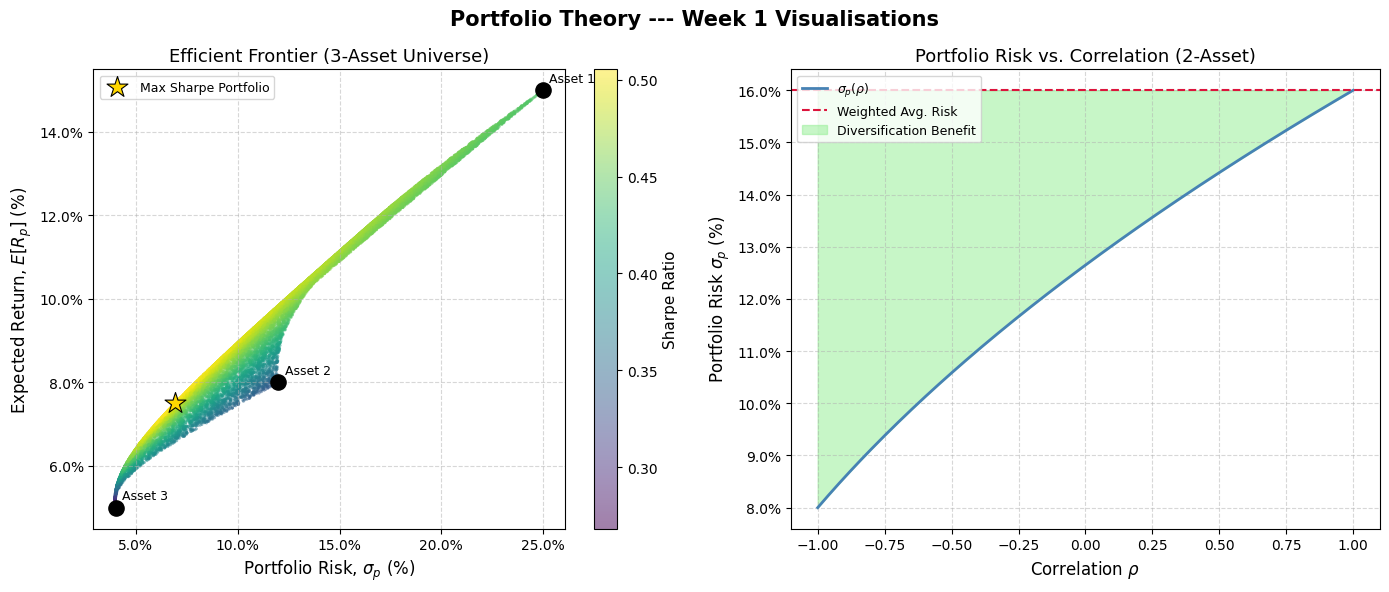


Q15 - Figure saved as 'week1_plots.png'


In [62]:


# create the figure with 2 subplots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- SUBPLOT 1: Efficient Frontier Scatter ----

# scatter all 20000 portfolios coloured by Sharpe ratio
sc = ax1.scatter(
    sigma_p_plot * 100,    # x-axis in percentage
    E_Rp_plot * 100,       # y-axis in percentage
    c=sharpe_plot,         # colour by Sharpe ratio
    cmap='viridis',        # viridis colormap
    alpha=0.5,             # semi-transparent to see density
    s=5,                   # small dot size for 20000 points
    linewidths=0           # no edge lines for cleaner look
)

# add colorbar for Sharpe ratio
cbar = plt.colorbar(sc, ax=ax1)
cbar.set_label('Sharpe Ratio', fontsize=11)

# mark the maximum Sharpe portfolio with a gold star
ax1.scatter(
    max_sig_plot * 100,
    max_ret_plot * 100,
    marker='*',
    s=250,
    color='gold',
    edgecolors='black',
    linewidths=0.8,
    zorder=5,
    label='Max Sharpe Portfolio'
)

# mark individual assets with large dark circles and annotate
for i in range(3):
    ax1.scatter(
        asset_sigmas[i] * 100,
        asset_mus[i] * 100,
        s=120,
        color='black',
        zorder=6
    )
    # annotate slightly to the right of each point
    ax1.annotate(
        asset_names[i],
        xy=(asset_sigmas[i] * 100, asset_mus[i] * 100),
        xytext=(asset_sigmas[i] * 100 + 0.3, asset_mus[i] * 100 + 0.2),
        fontsize=9,
        color='black'
    )

# axis labels and formatting
ax1.set_xlabel('Portfolio Risk, $\\sigma_p$ (%)', fontsize=12)
ax1.set_ylabel('Expected Return, $E[R_p]$ (%)', fontsize=12)
ax1.set_title('Efficient Frontier (3-Asset Universe)', fontsize=13)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# format axes as percentages (they are already in %, just add % sign)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# ---- SUBPLOT 2: Correlation Sensitivity ----

# reuse the Q12 arrays (rho_array and sigma_p_q12) already computed above
# weighted average risk = w1*sigma1 + w2*sigma2 (constant, no diversification)
weighted_avg_risk = w1_q12 * sigma1_q12 + w2_q12 * sigma2_q12

# convert to percentages for plotting
rho_plot_x   = rho_array
sigma_p_pct  = sigma_p_q12 * 100
wavg_pct     = weighted_avg_risk * 100

# plot sigma_p vs rho
ax2.plot(
    rho_plot_x,
    sigma_p_pct,
    color='steelblue',
    linewidth=2,
    label='$\\sigma_p(\\rho)$'
)

# horizontal dashed line at weighted average risk
ax2.axhline(
    y=wavg_pct,
    color='crimson',
    linestyle='--',
    linewidth=1.5,
    label='Weighted Avg. Risk'
)

# shade the region between sigma_p curve and the weighted average line
# where sigma_p < weighted_avg (the diversification benefit region)
ax2.fill_between(
    rho_plot_x,
    sigma_p_pct,          # lower bound: actual portfolio risk
    wavg_pct,             # upper bound: weighted average risk
    where=(sigma_p_pct < wavg_pct),  # only shade where diversification helps
    color='lightgreen',
    alpha=0.5,
    label='Diversification Benefit'
)

# axis labels and formatting
ax2.set_xlabel('Correlation $\\rho$', fontsize=12)
ax2.set_ylabel('Portfolio Risk $\\sigma_p$ (%)', fontsize=12)
ax2.set_title('Portfolio Risk vs. Correlation (2-Asset)', fontsize=13)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

# format y-axis as percentage
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# ---- Global Figure Settings ----
fig.suptitle('Portfolio Theory --- Week 1 Visualisations', fontsize=15, fontweight='bold')
plt.tight_layout()

# save the figure at 150 dpi
plt.savefig('week1_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nQ15 - Figure saved as 'week1_plots.png'")